# Zermelo Navigation (Continuous and Discrete)

Zermelo's problem — the time-optimal route across a sea with a current — is the physical reading of the **Randers metric**. We solve it on the smooth sphere and on a triangulated icosphere, and check that the discrete and continuous wind-aware geodesics agree. The 3-D scene is interactive: rotate it to see how the routes deflect from the great circle.

**Metric-first design.** A HAM `FinslerMetric` is specified by a single scalar field, the Finsler cost
$F(x, v)$, which defines the path energy
$$\mathcal{E}[\gamma] = \int \tfrac{1}{2}\, F^2(x, \dot{x})\, dt.$$
The geodesic spray, fundamental tensor, curvature, and Berwald parallel transport are then obtained by
automatic differentiation of $F$ with `jax.grad` / `jax.hessian`, rather than by hand-deriving
Christoffel symbols. The notebooks in this suite share a small plotting style (`ham.vis.style`) so the
figures stay consistent and readable.

## 1. Setup

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

from ham.geometry import Euclidean, Randers, Sphere, TriangularMesh
from ham.solvers import AVBDSolver
from ham.vis import generate_icosphere
from ham.vis.style import (use_ham_style, PALETTE, plotly_layout, plotly_sphere,
                           plotly_path, plotly_cones)

pio.renderers.default = "plotly_mimetype"
use_ham_style()
key = jax.random.PRNGKey(0)
sphere = Sphere(radius=1.0)

## 2. The Randers metric from Zermelo navigation

A current $W(x)$ over a Riemannian sea $h(x)$ gives the time-optimal cost
$$ F(x, v) = \frac{\sqrt{\lambda\,\|v\|_h^2 + \langle W, v\rangle_h^2} - \langle W, v\rangle_h}{\lambda},
\qquad \lambda = 1 - \|W\|_h^2, $$
valid under the causality bound $\|W\|_h < 1$. We use a trade wind: a rotation about the $z$-axis,
strongest at the equator and vanishing at the poles.

In [2]:
def w_net(x):
    return 0.9 * jnp.array([-x[1], x[0], 0.0])


def h_net(x):
    return jnp.eye(3)


metric_riem = Randers(sphere, h_net, lambda x: jnp.zeros(3))
metric_randers = Randers(sphere, h_net, w_net)

## 3. Equator to north pole

The shortest route is a meridian, which runs across the current; the time-optimal Randers route
deflects sideways to use the wind.

In [3]:
start = jnp.array([1.0, 0.0, 0.0])
end = jnp.array([0.0, 0.0, 1.0])

solver = AVBDSolver(step_size=0.05, beta=10.0, iterations=250, tol=1e-6)
traj_riem = solver.solve(metric_riem, start, end, n_steps=40, key=key)
traj_rand = solver.solve(metric_randers, start, end, n_steps=40, key=key)

batch_E = jax.vmap(metric_randers.energy)
e_riem = float(batch_E(traj_riem.xs[:-1], traj_riem.vs).sum())
e_rand = float(batch_E(traj_rand.xs[:-1], traj_rand.vs).sum())
print(f"energy  great circle (under wind): {e_riem:.4f}")
print(f"energy  Randers (wind-optimal)   : {e_rand:.4f}")

energy  great circle (under wind): 0.0475
energy  Randers (wind-optimal)   : 0.0416


## 4. The same problem on a mesh

We rebuild the sphere as a triangulated icosphere and solve again with a `Randers` metric **on the
mesh**. (Previously this leg used a plain `Euclidean` mesh metric, which reproduced the great circle and
could not show the wind.) The discrete Randers geodesic should track the continuous one.

In [4]:
verts, faces = generate_icosphere(radius=1.0, subdivisions=3)
mesh = TriangularMesh(verts, faces)
mesh_randers = Randers(mesh, h_net, w_net)
mesh_eucl = Euclidean(mesh)

traj_mesh_rand = solver.solve(mesh_randers, start, end, n_steps=40, key=key)
traj_mesh_eucl = solver.solve(mesh_eucl, start, end, n_steps=40, key=key)

sep = lambda a, b: float(jnp.max(jnp.linalg.norm(a.xs - b.xs, axis=1)))
print(f"discrete Randers vs discrete Euclidean : {sep(traj_mesh_rand, traj_mesh_eucl):.3f}  (wind now matters)")
print(f"discrete Randers vs continuous Randers : {sep(traj_mesh_rand, traj_rand):.3f}  (discrete tracks continuum)")

discrete Randers vs discrete Euclidean : 0.068  (wind now matters)
discrete Randers vs continuous Randers : 0.022  (discrete tracks continuum)


## 5. The wind field and the routes

The current is azimuthal everywhere, so we draw it over the whole sphere; cone size follows the wind
speed, which peaks at the equator and fades to zero at the poles. The wind-optimal routes (continuous
and discrete) deflect from the great circle in the direction of the current.

In [5]:
pts, _ = generate_icosphere(radius=1.0, subdivisions=3)
pts = np.array(pts)
W = np.array(jax.vmap(lambda p: sphere.to_tangent(p, w_net(p)))(jnp.array(pts)))
keep = np.linalg.norm(W, axis=1) > 0.06

fig = go.Figure()
fig.add_trace(plotly_sphere(1.0))
fig.add_trace(plotly_cones(pts[keep], W[keep], name="current", sizeref=0.3,
                           showscale=True, colorbar_title="wind speed"))
fig.add_trace(plotly_path(traj_riem.xs, color=PALETTE["muted"], name="great circle",
                          width=5, dash="dash"))
fig.add_trace(plotly_path(traj_rand.xs, color=PALETTE["accent"], name="continuous Randers", width=8))
fig.add_trace(plotly_path(traj_mesh_rand.xs, color=PALETTE["teal"], name="discrete-mesh Randers",
                          width=5, dash="dot", show_start=False))
plotly_layout(fig, "Zermelo navigation on the sphere")
fig.show()

## 6. The wind as a shifted indicatrix

At the equator (where the current is strongest) the Riemannian indicatrix is a centred circle and the
Randers indicatrix is an off-centre ellipse: the boat reaches farther downwind than upwind for the same
unit of time.

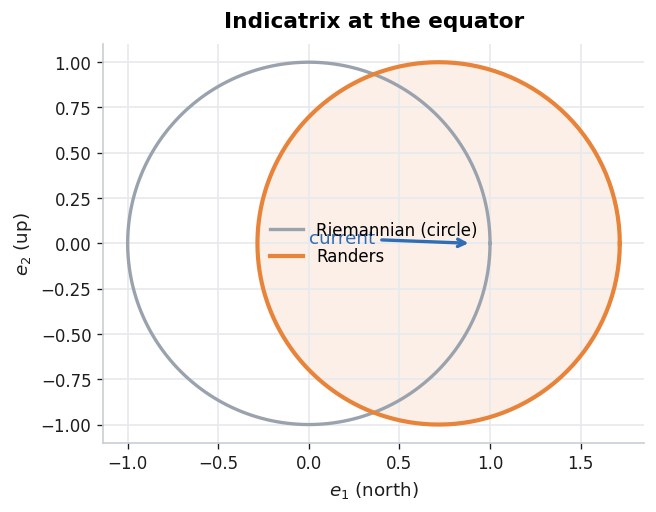

In [6]:
p = jnp.array([1.0, 0.0, 0.0])
e1 = sphere.to_tangent(p, jnp.array([0.0, 1.0, 0.0])); e1 = e1 / jnp.linalg.norm(e1)
e2 = sphere.to_tangent(p, jnp.array([0.0, 0.0, 1.0])); e2 = e2 / jnp.linalg.norm(e2)
ths = np.linspace(0, 2 * np.pi, 220)


def indicatrix(metric):
    rad = np.array([1.0 / float(metric.metric_fn(p, jnp.cos(t) * e1 + jnp.sin(t) * e2)) for t in ths])
    return rad * np.cos(ths), rad * np.sin(ths)


xr, yr = indicatrix(metric_riem)
xw, yw = indicatrix(metric_randers)
wv = np.array(sphere.to_tangent(p, w_net(p)))
wc = np.array([np.dot(wv, np.array(e1)), np.dot(wv, np.array(e2))])

fig, ax = plt.subplots(figsize=(5.6, 5.6))
ax.plot(xr, yr, color=PALETTE["muted"], lw=2, label="Riemannian (circle)")
ax.fill(xw, yw, color=PALETTE["accent"], alpha=0.12)
ax.plot(xw, yw, color=PALETTE["accent"], lw=2.5, label="Randers")
ax.annotate("current", xy=(wc[0], wc[1]), xytext=(0, 0), color=PALETTE["primary"],
            arrowprops=dict(arrowstyle="->", color=PALETTE["primary"], lw=2))
ax.set_aspect("equal"); ax.legend()
ax.set_title("Indicatrix at the equator")
ax.set_xlabel("$e_1$ (north)"); ax.set_ylabel("$e_2$ (up)")
plt.tight_layout(); plt.show()

## 7. Notes

* The Randers geodesic trades distance for travel time, deflecting across the current — the Zermelo
  solution, obtained from a generic AVBD relaxation.
* Putting the wind on the mesh (not a plain Euclidean metric) makes the discrete route wind-aware, and
  it agrees with the continuum: the discrete and smooth geometries share one solver.